# Q1: Supervised Learning — Heart Disease Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
try:
    df = pd.read_csv('../data/q1_heart_disease.csv')
except Exception:
    df = pd.read_csv('q1_heart_disease.csv')
print('Loaded df with shape:', df.shape)


Loaded df with shape: (800, 12)


In [2]:
# Data Inspection
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isna().sum())
print()
print('Head:')
print(df.head())

Shape: (800, 12)

Dtypes:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Head:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0      

## Exploratory Data Analysis

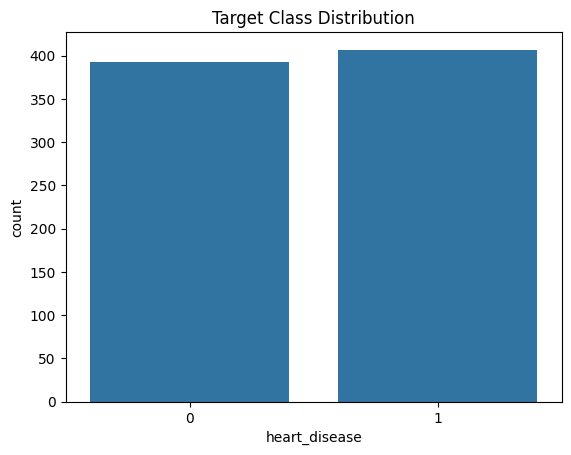

In [3]:
# Target Class Distribution
sns.countplot(x='heart_disease', data=df)
plt.title('Target Class Distribution')
plt.show()

The target variable is moderately balanced, indicating that accuracy alone may be misleading and precision/recall should be considered.

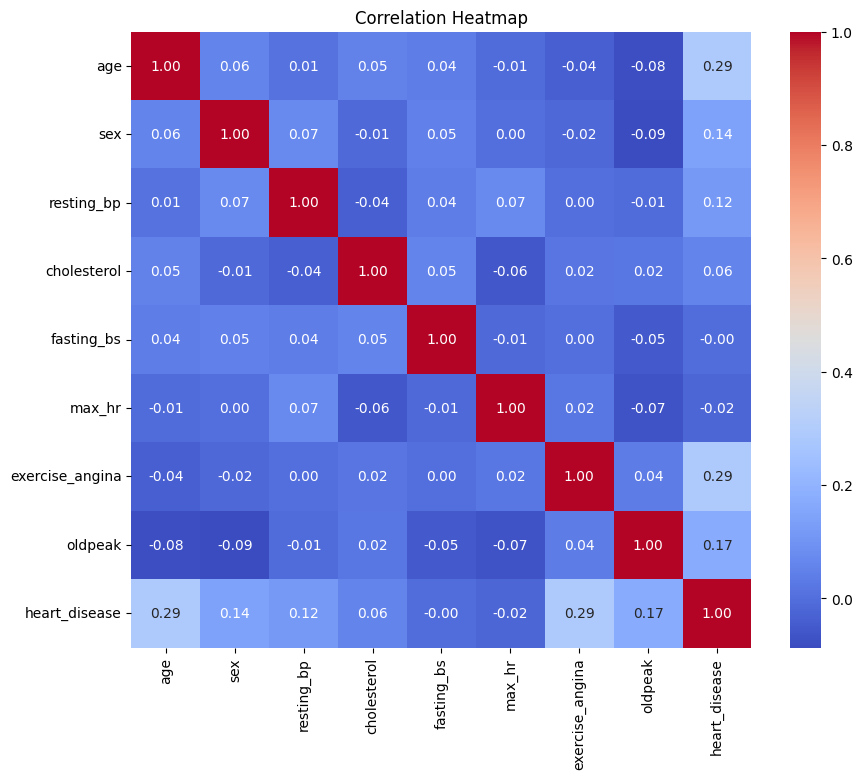

In [4]:
# Correlation Heatmap (numeric only)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Several numerical variables (e.g., age, max_hr, oldpeak) show meaningful correlations with heart disease, suggesting predictive signal.

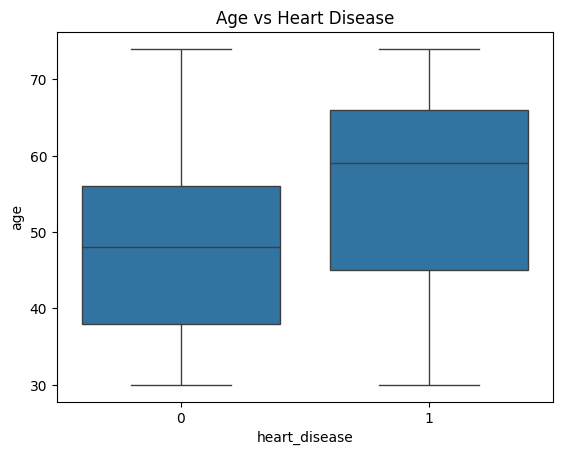

In [5]:
# Boxplot of Age vs Heart Disease
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.show()

Patients with heart disease tend to be older on average, reinforcing age as an important predictor.

## Data Preprocessing

Missing values are handled using median imputation for numerical variables to reduce the impact of outliers and preserve data size.

In [6]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (640, 11) Test shape: (160, 11)


## Model Training

In [7]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print('--- %s ---' % name)
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

--- Decision Tree ---
Confusion Matrix:
[[56 23]
 [22 59]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

--- Random Forest ---
Confusion Matrix:
[[60 19]
 [15 66]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [18 63]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79
           1       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



Gradient Boosting performs best overall, achieving the strongest balance between precision and recall on the positive (disease) class. This makes it preferable in a healthcare context where false negatives are costly.

## Hyperparameter Tuning

In [8]:
params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}
pipe = Pipeline([('preprocess', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
grid = GridSearchCV(pipe, params, scoring='f1', cv=5)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
y_pred = grid.best_estimator_.predict(X_test)
print('Tuned model performance:')
print(classification_report(y_test, y_pred))

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Tuned model performance:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        79
           1       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

